# Cross-layer EDA 03: Molecular context to CRISPR dependency

This notebook asks the central conditional-dependency question:

> When **Gene A** has a particular molecular state, does the cell become more dependent on **Gene B**?

Gene A supplies the biological context. Gene B is knocked out in a CRISPR screen. A stronger loss of cell fitness after knocking out Gene B suggests that Gene B may be a vulnerability in that context.

## Context routes

1. Gene A mutation state.
2. Gene A copy-number loss or gain.
3. Gene A RNA-high versus RNA-low state within lineage.
4. Whole-genome signatures such as MSI, loss of heterozygosity, WGD, CIN, and aneuploidy.

## Outcome

`CRISPRGeneEffect` is primary. More negative values mean the knockout harmed cell growth more strongly. `CRISPRGeneDependency` is supporting evidence, where larger values mean a higher inferred probability of dependency.

For interpretability, this notebook reports a **dependency shift** where positive values always mean that the molecular-context group is more dependent on Gene B.

## Guardrails

- Use `model_id` as the only automatic model join key.
- Use exact gene columns from `gene_master`.
- Report context and reference group sizes for every comparison.
- Adjust for broad lineage and do not interpret tiny groups.
- Keep mutation definitions, copy-number states, and RNA thresholds visible.
- Use released CRISPR values as outcomes; QC, library, growth, and efficacy remain confidence context.
- Do not remove numerical QC outliers automatically.
- Flag common-essential targets because broad essentiality is not the same as selective dependency.
- Treat broad pair rankings as exploratory EDA, not validated biological discoveries.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'gene_master': DATA / 'architecture' / 'gene_master.csv',
    'crispr_context': DATA / 'architecture' / 'model_crispr_context.csv',
    'effect': DATA / 'raw' / 'CRISPRGeneEffect.csv',
    'dependency': DATA / 'raw' / 'CRISPRGeneDependency.csv',
    'common_essentials': DATA / 'raw' / 'CRISPRInferredCommonEssentials.csv',
    'mutations': DATA / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'copy_number': DATA / 'raw' / 'OmicsAbsoluteCNGene.csv',
    'expression': DATA / 'derived' / 'expression_default_rna_model.csv',
    'signatures': DATA / 'derived' / 'signatures_model.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)
crispr_context = pd.read_csv(PATHS['crispr_context'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
signatures = pd.read_csv(PATHS['signatures'], low_memory=False).set_index('model_id')
common_essentials = pd.read_csv(PATHS['common_essentials'])

assert master['model_id'].is_unique
assert gene_master['symbol'].is_unique
assert crispr_context['model_id'].is_unique

print(f'Identity spine: {len(master):,} models')
print(f'CRISPR context models: {len(crispr_context):,}')
print(f'Mutation summaries: {len(mutations):,} model-gene rows')
print(f'Genomic-signature models: {len(signatures):,}')

Identity spine: 2,105 models
CRISPR context models: 1,178
Mutation summaries: 646,941 model-gene rows
Genomic-signature models: 1,929


## Column dictionary

| Column | Meaning | Project use |
|---|---|---|
| `model_id` | Stable DepMap identifier for one cell-line model. | Only automatic model-level join key. |
| `oncotree_lineage` | Broad cancer lineage. | Controls for tissue-driven molecular and dependency differences. |
| `context_type` | Mutation, copy number, RNA, or genomic signature. | Keeps biologically different hypotheses separate. |
| `context_name` | Gene A or signature defining the context. | First part of the conditional-dependency pair. |
| `target_gene` | Gene B knocked out by CRISPR. | Candidate vulnerability. |
| `context_definition` | Exact rule used to form the context group. | Makes altered/high/loss/gain definitions auditable. |
| `context_models` | Models meeting the context rule and having the outcome. | Context-group denominator. |
| `reference_models` | Measured models meeting the reference rule. | Comparison-group denominator. |
| `median_gene_effect_context` | Median CRISPR gene effect in the context group. | More negative means stronger dependency. |
| `median_gene_effect_reference` | Median CRISPR gene effect in the reference group. | Baseline comparison. |
| `dependency_shift` | Reference median effect minus context median effect. | Positive means the context group is more dependent. |
| `dependency_rank_effect` | Reversed rank-biserial effect on CRISPR gene effect. | Positive means context values are generally more dependency-like. |
| `dependency_probability_shift` | Context median dependency probability minus reference median. | Supporting probability-scale evidence. |
| `lineage_adjusted_models` | Models retained in lineages with at least 15 observations. | Denominator for lineage-adjusted effects. |
| `lineage_adjusted_dependency_shift` | Dependency shift after subtracting lineage medians. | Reduces broad tissue confounding. |
| `continuous_dependency_rho` | Reversed lineage-adjusted Spearman correlation. | Positive means higher context value associates with stronger dependency. |
| `is_common_essential` | Gene B belongs to the inferred common-essential list. | Warns that dependency may be broad rather than selective. |
| `baseline_median_gene_effect` | Gene B median effect across all CRISPR models. | Shows background essentiality. |
| `inference_libraries` | CRISPR library or library combination contributing to a model. | Sensitivity and provenance context. |
| `n_numeric_review_flags` | Count of within-library IQR review flags across QC/growth/efficacy measures. | Review context only; not an automatic exclusion rule. |
| `evaluable_lineages` | Lineages containing at least five context and five reference models. | Shows whether an effect can be checked across disease contexts. |

## 1. Analysis genes, outcomes, and route coverage

The notebook uses a focused hypothesis panel. It is large enough to compare several biological routes without pretending to be an exhaustive genome-wide discovery screen.

,route,models,pct_of_crispr_panel
0,Mutation to CRISPR,1178,100.000000
1,Copy number to CRISPR,948,80.475382
2,RNA to CRISPR,1103,93.633277
3,Signatures to CRISPR,1178,100.000000


,target_gene,baseline_median_gene_effect,baseline_median_dependency_probability,models_effect_at_or_below_minus_0_5_pct,is_common_essential
13,WEE1,-2.485163,1.000000,100.000000,1
14,CHEK1,-1.866716,1.000000,100.000000,1
7,MAT2A,-1.748636,0.999978,98.726655,1
17,RAD51,-1.441631,0.996875,99.405772,1
12,ATR,-1.344573,0.993535,99.235993,1
19,MTOR,-1.167524,0.984875,98.641766,1
6,PRMT5,-1.016544,0.974173,94.142615,1
21,BCL2L1,-0.909607,0.959314,84.634975,1
16,FEN1,-0.803912,0.929216,80.645161,1
22,MCL1,-0.676386,0.826437,70.713073,1


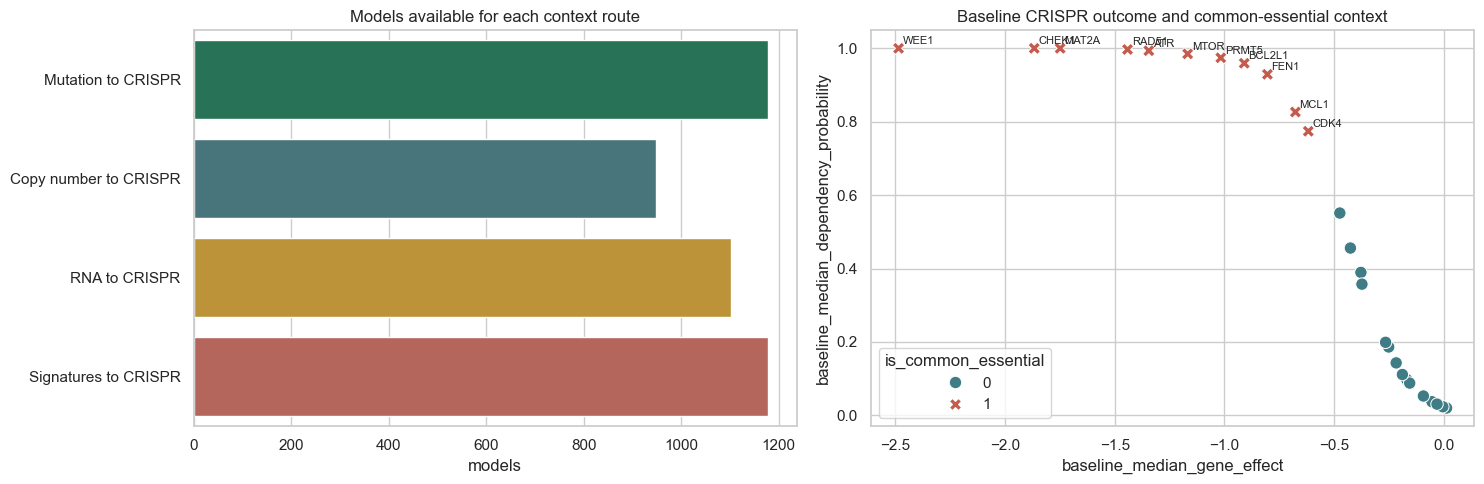

In [2]:
CONTEXT_GENES = [
    'TP53', 'BRCA1', 'BRCA2', 'ARID1A', 'KRAS', 'BRAF', 'PIK3CA', 'PTEN',
    'RB1', 'CDKN2A', 'MYC', 'ERBB2', 'EGFR', 'MDM2', 'ALK', 'EML4',
    'MTAP', 'SMARCA4', 'STK11', 'KEAP1', 'APC'
]
TARGET_GENES = [
    'EZH2', 'SMARCA2', 'PARP1', 'RAF1', 'MAPK1', 'WRN', 'PRMT5', 'MAT2A',
    'EGFR', 'ERBB2', 'CDK4', 'MDM2', 'ATR', 'WEE1', 'CHEK1', 'POLQ',
    'FEN1', 'RAD51', 'AKT1', 'MTOR', 'BCL2', 'BCL2L1', 'MCL1', 'PIK3CA',
    'KRAS', 'BRAF', 'BRCA1', 'BRCA2'
]

gene_lookup = gene_master.set_index('symbol')
context_gene_table = gene_lookup.loc[CONTEXT_GENES, ['gene_id', 'expression_column', 'copy_number_column']].reset_index()
target_gene_table = gene_lookup.loc[TARGET_GENES, ['gene_id', 'crispr_effect_column', 'crispr_dependency_column', 'is_crispr_common_essential']].reset_index()

effect_usecols = ['Unnamed: 0', *target_gene_table['crispr_effect_column'].tolist()]
dependency_usecols = ['Unnamed: 0', *target_gene_table['crispr_dependency_column'].tolist()]
effect = pd.read_csv(PATHS['effect'], usecols=effect_usecols).rename(columns={'Unnamed: 0': 'model_id', **target_gene_table.set_index('crispr_effect_column')['symbol'].to_dict()}).set_index('model_id')
dependency = pd.read_csv(PATHS['dependency'], usecols=dependency_usecols).rename(columns={'Unnamed: 0': 'model_id', **target_gene_table.set_index('crispr_dependency_column')['symbol'].to_dict()}).set_index('model_id')

copy_number = pd.read_csv(PATHS['copy_number'], usecols=['Unnamed: 0', *context_gene_table['copy_number_column'].tolist()]).rename(columns={'Unnamed: 0': 'model_id', **context_gene_table.set_index('copy_number_column')['symbol'].to_dict()}).set_index('model_id')
expression = pd.read_csv(PATHS['expression'], usecols=['model_id', *context_gene_table['expression_column'].tolist()]).rename(columns=context_gene_table.set_index('expression_column')['symbol'].to_dict()).set_index('model_id')

assert effect.index.is_unique and dependency.index.is_unique
assert effect.index.equals(dependency.index)
assert set(effect.columns) == set(TARGET_GENES)
assert set(copy_number.columns) == set(expression.columns) == set(CONTEXT_GENES)

model_context = master[['model_id', 'oncotree_lineage', 'has_mutation_assay', 'has_expression', 'has_absolute_copy_number', 'has_genomic_signatures']].copy()
model_context['oncotree_lineage'] = model_context['oncotree_lineage'].fillna('Unknown')
lineage_lookup = model_context.set_index('model_id')['oncotree_lineage']
crispr_ids = set(effect.index)

route_flags = {
    'Mutation to CRISPR': 'has_mutation_assay',
    'Copy number to CRISPR': 'has_absolute_copy_number',
    'RNA to CRISPR': 'has_expression',
    'Signatures to CRISPR': 'has_genomic_signatures',
}
route_rows = []
route_ids = {}
for route, flag in route_flags.items():
    ids = crispr_ids & set(master.loc[master[flag].fillna(0).eq(1), 'model_id'])
    route_ids[route] = ids
    route_rows.append({'route': route, 'models': len(ids), 'pct_of_crispr_panel': 100 * len(ids) / len(crispr_ids)})
route_coverage = pd.DataFrame(route_rows)
display(route_coverage)

target_common = target_gene_table.set_index('symbol')['is_crispr_common_essential'].fillna(0).astype(int).to_dict()
target_summary = pd.DataFrame({
    'target_gene': TARGET_GENES,
    'baseline_median_gene_effect': [effect[g].median() for g in TARGET_GENES],
    'baseline_median_dependency_probability': [dependency[g].median() for g in TARGET_GENES],
    'models_effect_at_or_below_minus_0_5_pct': [100 * effect[g].le(-0.5).mean() for g in TARGET_GENES],
    'is_common_essential': [target_common[g] for g in TARGET_GENES],
})
display(target_summary.sort_values('baseline_median_gene_effect'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=route_coverage, x='models', y='route', hue='route', legend=False, palette=['#1b7f5a', '#3f7c85', '#d39b24', '#c45b4d'], ax=axes[0])
axes[0].set_title('Models available for each context route'); axes[0].set_ylabel('')
sns.scatterplot(data=target_summary, x='baseline_median_gene_effect', y='baseline_median_dependency_probability', hue='is_common_essential', style='is_common_essential', palette={0: '#3f7c85', 1: '#c45b4d'}, s=80, ax=axes[1])
for _, row in target_summary.loc[target_summary['is_common_essential'].eq(1)].iterrows():
    axes[1].annotate(row['target_gene'], (row['baseline_median_gene_effect'], row['baseline_median_dependency_probability']), fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[1].set_title('Baseline CRISPR outcome and common-essential context')
plt.tight_layout(); plt.show()

### What this means for the project

The route denominator is the intersection of CRISPR with the relevant molecular assay. It is not the full identity spine and it is not automatically the same for mutation, RNA, and copy number.

Gene effect and dependency probability describe related but different outcome scales. A common-essential target can still show a context shift, but the dashboard must say that the gene is already broadly important for cell survival.

**Example:** PRMT5 can appear more dependency-like in an MTAP-loss context while also being a common essential. The selective shift and broad baseline dependency must be presented together.

## 2. Statistical definitions

Every comparison is calculated from explicit context and reference model sets. Positive dependency shifts always mean stronger Gene B dependency in the context group.

In [3]:
def rank_biserial(left: np.ndarray, right: np.ndarray) -> float:
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    if len(left) == 0 or len(right) == 0:
        return np.nan
    ranks = rankdata(np.concatenate([left, right]))
    u_left = ranks[:len(left)].sum() - len(left) * (len(left) + 1) / 2
    return 2 * u_left / (len(left) * len(right)) - 1


def dependency_comparison(target_gene: str, context_ids: set, reference_ids: set, allowed_ids: set | None = None) -> dict:
    assert context_ids.isdisjoint(reference_ids)
    available = set(effect.index) & set(dependency.index)
    if allowed_ids is not None:
        available &= set(allowed_ids)
    context = sorted(context_ids & available)
    reference = sorted(reference_ids & available)
    selected = context + reference
    frame = pd.DataFrame({
        'gene_effect': effect.loc[selected, target_gene],
        'dependency_probability': dependency.loc[selected, target_gene],
        'lineage': lineage_lookup.reindex(selected),
        'group': ['Context'] * len(context) + ['Reference'] * len(reference),
    }).dropna(subset=['gene_effect', 'dependency_probability', 'lineage'])
    context_effect = frame.loc[frame['group'].eq('Context'), 'gene_effect'].to_numpy()
    reference_effect = frame.loc[frame['group'].eq('Reference'), 'gene_effect'].to_numpy()
    context_probability = frame.loc[frame['group'].eq('Context'), 'dependency_probability'].to_numpy()
    reference_probability = frame.loc[frame['group'].eq('Reference'), 'dependency_probability'].to_numpy()

    keep = frame.groupby('lineage')['gene_effect'].transform('size').ge(15)
    adjusted = frame.loc[keep].copy()
    adjusted['effect_residual'] = adjusted['gene_effect'] - adjusted.groupby('lineage')['gene_effect'].transform('median')
    adjusted_context = adjusted.loc[adjusted['group'].eq('Context'), 'effect_residual'].to_numpy()
    adjusted_reference = adjusted.loc[adjusted['group'].eq('Reference'), 'effect_residual'].to_numpy()
    adjusted_usable = len(adjusted_context) >= 10 and len(adjusted_reference) >= 10 and len(adjusted) >= 30

    return {
        'context_models': len(context_effect),
        'reference_models': len(reference_effect),
        'median_gene_effect_context': np.median(context_effect) if len(context_effect) else np.nan,
        'median_gene_effect_reference': np.median(reference_effect) if len(reference_effect) else np.nan,
        'dependency_shift': np.median(reference_effect) - np.median(context_effect) if len(context_effect) and len(reference_effect) else np.nan,
        'dependency_rank_effect': -rank_biserial(context_effect, reference_effect),
        'dependency_probability_shift': np.median(context_probability) - np.median(reference_probability) if len(context_probability) and len(reference_probability) else np.nan,
        'lineage_adjusted_models': len(adjusted),
        'lineage_adjusted_context_models': len(adjusted_context),
        'lineage_adjusted_reference_models': len(adjusted_reference),
        'lineage_adjusted_dependency_shift': np.median(adjusted_reference) - np.median(adjusted_context) if adjusted_usable else np.nan,
        'lineage_adjusted_rank_effect': -rank_biserial(adjusted_context, adjusted_reference) if adjusted_usable else np.nan,
    }


def within_lineage_extremes(values: pd.Series, allowed_ids: set, lower_q: float = 0.2, upper_q: float = 0.8) -> tuple[set, set]:
    ids = sorted(set(values.index) & set(allowed_ids))
    frame = pd.DataFrame({'value': values.reindex(ids), 'lineage': lineage_lookup.reindex(ids)}).dropna()
    keep = frame.groupby('lineage')['value'].transform('size').ge(15)
    frame = frame.loc[keep].copy()
    frame['lower'] = frame.groupby('lineage')['value'].transform(lambda s: s.quantile(lower_q))
    frame['upper'] = frame.groupby('lineage')['value'].transform(lambda s: s.quantile(upper_q))
    low = set(frame.index[frame['value'].le(frame['lower'])])
    high = set(frame.index[frame['value'].ge(frame['upper'])])
    overlap = low & high
    return high - overlap, low - overlap


def continuous_dependency_association(context_values: pd.Series, target_gene: str, allowed_ids: set) -> tuple[int, float]:
    ids = sorted(set(context_values.index) & set(effect.index) & set(allowed_ids))
    frame = pd.DataFrame({
        'context': context_values.reindex(ids),
        'gene_effect': effect.loc[ids, target_gene],
        'lineage': lineage_lookup.reindex(ids),
    }).dropna()
    keep = frame.groupby('lineage')['context'].transform('size').ge(15)
    frame = frame.loc[keep].copy()
    if len(frame) < 30:
        return len(frame), np.nan
    frame[['context_residual', 'effect_residual']] = frame[['context', 'gene_effect']] - frame.groupby('lineage')[['context', 'gene_effect']].transform('median')
    return len(frame), -frame['context_residual'].corr(frame['effect_residual'], method='spearman')


comparison_masks = {}
print('Positive dependency_shift, dependency_rank_effect, and continuous_dependency_rho all mean stronger dependency in the context direction.')

Positive dependency_shift, dependency_rank_effect, and continuous_dependency_rho all mean stronger dependency in the context direction.


### What this means for the project

The sign convention is deliberately consistent. A positive result always points toward stronger Gene B dependency in the molecular context, even though raw CRISPR gene-effect values become more negative when dependency strengthens.

Lineage adjustment subtracts the median value within sufficiently large lineages. This reduces broad tissue differences but does not prove causality or remove every confounder.

**Example:** if KRAS-mutant models are mostly from one lineage, a raw RAF1 effect can reflect both KRAS state and lineage. The adjusted effect asks whether mutant models remain more RAF1-dependent after broad lineage medians are removed.

## 3. Mutation context to CRISPR dependency

Mutation absence is treated as a reference state only in mutation-assayed models. Any recorded variant and damaging/driver-like definitions remain separate.

,context_type,context_name,target_gene,context_definition,context_models,reference_models,median_gene_effect_context,median_gene_effect_reference,dependency_shift,dependency_rank_effect,dependency_probability_shift,lineage_adjusted_models,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift,lineage_adjusted_rank_effect,is_common_essential,baseline_median_gene_effect
276,Mutation,KRAS,KRAS,Damaging or driver-like,176,1002,-1.580796,-0.328631,1.252165,0.939258,0.710669,1143,173,970,0.659952,0.648054,0,-0.373204
248,Mutation,KRAS,KRAS,Any recorded variant,186,992,-1.549889,-0.327825,1.222064,0.916927,0.711673,1143,183,960,0.641896,0.645913,0,-0.373204
387,Mutation,PIK3CA,PIK3CA,Damaging or driver-like,123,1055,-0.879477,-0.395624,0.483853,0.654098,0.547795,1143,121,1022,0.364059,0.599214,0,-0.426307
359,Mutation,PIK3CA,PIK3CA,Any recorded variant,140,1038,-0.838398,-0.394307,0.444091,0.605133,0.538309,1143,138,1005,0.307317,0.547494,0,-0.426307
333,Mutation,BRAF,BRAF,Damaging or driver-like,98,1080,-0.934389,-0.021715,0.912674,0.768745,0.944732,1143,90,1053,0.262385,0.489016,0,-0.030936
754,Mutation,MDM2,BRCA1,Any recorded variant,17,1161,-0.607093,-0.424761,0.182331,0.322997,0.278370,1143,17,1126,0.251214,0.331418,0,-0.425698
312,Mutation,BRAF,MAPK1,Damaging or driver-like,98,1080,-0.654346,-0.205689,0.448657,0.621466,0.603297,1143,90,1053,0.187003,0.331265,0,-0.217205
305,Mutation,BRAF,BRAF,Any recorded variant,125,1053,-0.754030,-0.019914,0.734116,0.680988,0.864484,1143,117,1026,0.179047,0.430283,0,-0.030936
845,Mutation,EML4,WRN,Any recorded variant,28,1150,-0.185871,-0.051818,0.134053,0.425217,0.061226,1143,27,1116,0.127779,0.425528,0,-0.054037
284,Mutation,BRAF,MAPK1,Any recorded variant,125,1053,-0.494007,-0.205585,0.288422,0.523176,0.521478,1143,117,1026,0.126182,0.247963,0,-0.217205


,context_type,context_name,target_gene,context_definition,context_models,reference_models,median_gene_effect_context,median_gene_effect_reference,dependency_shift,dependency_rank_effect,dependency_probability_shift,lineage_adjusted_models,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift,lineage_adjusted_rank_effect,is_common_essential,baseline_median_gene_effect
11,Mutation,TP53,MDM2,Any recorded variant,790,388,-0.320773,-1.097491,-0.776718,-0.743553,-0.697174,1143,768,375,-0.509483,-0.613576,0,-0.377859
39,Mutation,TP53,MDM2,Damaging or driver-like,765,413,-0.320401,-1.058536,-0.738135,-0.707544,-0.693975,1143,744,399,-0.469683,-0.572439,0,-0.377859
724,Mutation,EGFR,KRAS,Damaging or driver-like,17,1161,-0.265522,-0.375501,-0.109979,-0.315397,-0.132795,1143,17,1126,-0.153863,-0.423153,0,-0.373204
670,Mutation,ERBB2,BRCA1,Damaging or driver-like,12,1166,-0.428129,-0.425698,0.002430,0.001858,-0.000271,1143,11,1132,-0.112359,-0.112753,0,-0.425698
1003,Mutation,SMARCA4,PIK3CA,Damaging or driver-like,64,1114,-0.352869,-0.430051,-0.077182,-0.150864,-0.161797,1143,61,1082,-0.104423,-0.172692,0,-0.426307
671,Mutation,ERBB2,BRCA2,Damaging or driver-like,12,1166,-0.473417,-0.474076,-0.000659,-0.025586,-0.009627,1143,11,1132,-0.096215,-0.171860,0,-0.474076
662,Mutation,ERBB2,AKT1,Damaging or driver-like,12,1166,-0.027880,-0.093412,-0.065532,-0.131361,-0.016134,1143,11,1132,-0.091410,-0.175233,0,-0.093084
648,Mutation,ERBB2,MAPK1,Damaging or driver-like,12,1166,-0.151437,-0.217622,-0.066185,-0.153087,-0.062577,1143,11,1132,-0.086690,-0.203020,0,-0.217205
331,Mutation,BRAF,PIK3CA,Damaging or driver-like,98,1080,-0.286709,-0.439879,-0.153169,-0.370881,-0.259050,1143,90,1053,-0.086227,-0.235454,0,-0.426307
815,Mutation,ALK,RAF1,Damaging or driver-like,16,1162,-0.144465,-0.155475,-0.011010,-0.069277,-0.009607,1143,16,1127,-0.082511,-0.258651,0,-0.155475


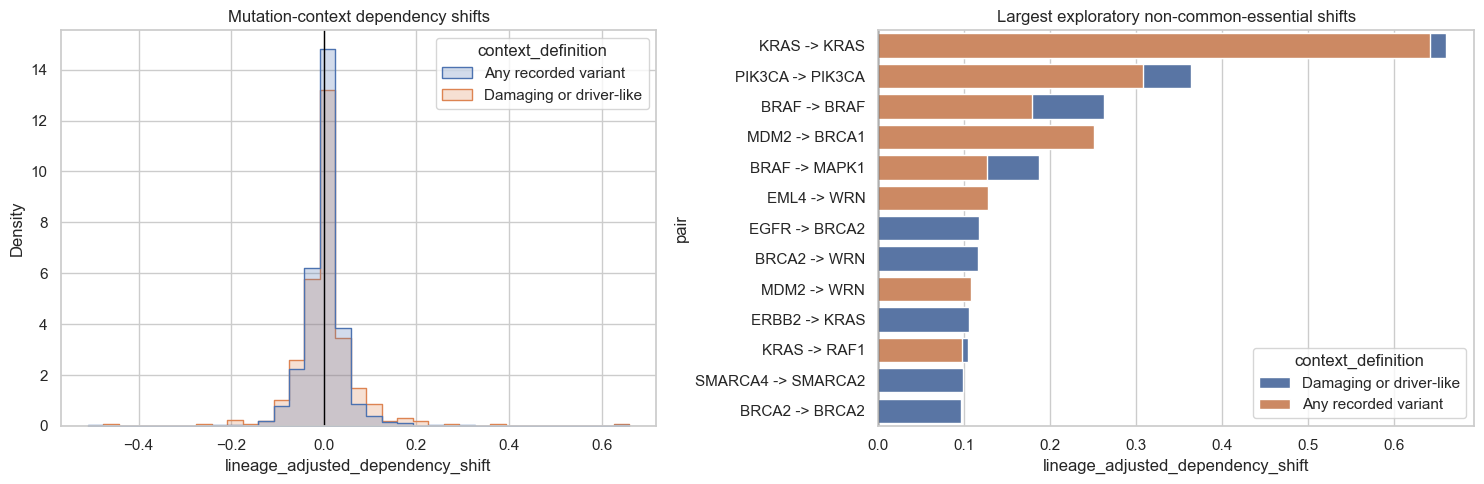

In [4]:
mutations['damaging_or_driver'] = (
    mutations['has_likely_lof'].eq(1)
    | mutations['highest_vep_impact'].eq('HIGH')
    | mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
)
mutation_universe = route_ids['Mutation to CRISPR']
mutation_rows = []
for context_gene in CONTEXT_GENES:
    gene_events = mutations.loc[mutations['hugo_symbol'].eq(context_gene)]
    definitions = {
        'Any recorded variant': set(gene_events['model_id']) & mutation_universe,
        'Damaging or driver-like': set(gene_events.loc[gene_events['damaging_or_driver'], 'model_id']) & mutation_universe,
    }
    for definition, context_set in definitions.items():
        reference_set = mutation_universe - context_set
        comparison_masks[('Mutation', context_gene, definition)] = (context_set, reference_set)
        for target_gene in TARGET_GENES:
            stats = dependency_comparison(target_gene, context_set, reference_set, mutation_universe)
            mutation_rows.append({'context_type': 'Mutation', 'context_name': context_gene, 'target_gene': target_gene, 'context_definition': definition, **stats})

mutation_results = pd.DataFrame(mutation_rows)
mutation_results['is_common_essential'] = mutation_results['target_gene'].map(target_common)
mutation_results['baseline_median_gene_effect'] = mutation_results['target_gene'].map(target_summary.set_index('target_gene')['baseline_median_gene_effect'])
mutation_usable = mutation_results.loc[
    mutation_results['lineage_adjusted_context_models'].ge(10)
    & mutation_results['lineage_adjusted_reference_models'].ge(10)
].copy()

display(mutation_usable.loc[mutation_usable['is_common_essential'].eq(0)].nlargest(25, 'lineage_adjusted_dependency_shift'))
display(mutation_usable.loc[mutation_usable['is_common_essential'].eq(0)].nsmallest(25, 'lineage_adjusted_dependency_shift'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=mutation_usable, x='lineage_adjusted_dependency_shift', hue='context_definition', bins=35, element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1); axes[0].set_title('Mutation-context dependency shifts')
top_mutation = mutation_usable.loc[mutation_usable['is_common_essential'].eq(0)].nlargest(18, 'lineage_adjusted_dependency_shift').copy()
top_mutation['pair'] = top_mutation['context_name'] + ' -> ' + top_mutation['target_gene']
sns.barplot(data=top_mutation, x='lineage_adjusted_dependency_shift', y='pair', hue='context_definition', dodge=False, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1); axes[1].set_title('Largest exploratory non-common-essential shifts')
plt.tight_layout(); plt.show()

### What this means for the project

A positive shift means Gene B knockout is more damaging in models carrying the Gene A mutation definition. The narrower damaging/driver-like rule can be more biologically specific but often has fewer models.

The strongest rows are exploratory leads, not answer keys. Many context-target combinations are inspected, and no experimental validation is performed here.

**Example:** ARID1A-altered versus reference models can be compared for EZH2 dependency, but the interpretation must include how ARID1A alteration was defined, both group sizes, lineage adjustment, and EZH2's baseline dependency.

## 4. Copy-number context to CRISPR dependency

Loss-like models (`CN <= 1`) and gain-like models (`CN >= 4`) are each compared with a near-diploid reference (`1 < CN < 4`). These are transparent EDA rules, not universal biological cut-offs.

,context_type,context_name,target_gene,context_definition,context_models,reference_models,median_gene_effect_context,median_gene_effect_reference,dependency_shift,dependency_rank_effect,dependency_probability_shift,lineage_adjusted_models,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift,lineage_adjusted_rank_effect,is_common_essential,baseline_median_gene_effect
643,Copy number,ERBB2,BRCA2,Loss-like (CN <= 1) vs near-diploid,13,613,-0.653754,-0.481667,0.172087,0.255616,0.071207,541,13,528,0.151734,0.282634,0,-0.474076
64,Copy number,BRCA1,EGFR,Loss-like (CN <= 1) vs near-diploid,18,633,-0.278765,-0.181164,0.097601,0.144989,0.100979,575,16,559,0.122463,0.273032,0,-0.188838
642,Copy number,ERBB2,BRCA1,Loss-like (CN <= 1) vs near-diploid,13,613,-0.609043,-0.430147,0.178896,0.280713,0.230005,541,13,528,0.122289,0.243881,0,-0.425698
250,Copy number,KRAS,BRCA1,Loss-like (CN <= 1) vs near-diploid,14,568,-0.502176,-0.426799,0.075377,0.155684,0.071569,469,11,458,0.114815,0.345772,0,-0.425698
786,Copy number,ALK,PARP1,Loss-like (CN <= 1) vs near-diploid,10,663,-0.271499,-0.167664,0.103834,0.223831,0.141154,604,10,594,0.097900,0.183838,0,-0.169220
1087,Copy number,KEAP1,PIK3CA,Loss-like (CN <= 1) vs near-diploid,12,727,-0.524698,-0.433690,0.091008,0.122192,0.047560,691,11,680,0.089320,0.001872,0,-0.426307
288,Copy number,BRAF,EGFR,Loss-like (CN <= 1) vs near-diploid,21,580,-0.448018,-0.199200,0.248818,0.253859,0.275850,513,19,494,0.088183,0.278287,0,-0.188838
135,Copy number,BRCA2,PIK3CA,Loss-like (CN <= 1) vs near-diploid,50,702,-0.457609,-0.420983,0.036627,0.025527,0.052585,699,44,655,0.082300,0.137058,0,-0.426307
228,Copy number,KRAS,MAPK1,Loss-like (CN <= 1) vs near-diploid,14,568,-0.236342,-0.213902,0.022440,0.193410,0.045263,469,11,458,0.078732,0.242954,0,-0.217205
1138,Copy number,APC,AKT1,Loss-like (CN <= 1) vs near-diploid,20,657,-0.120364,-0.088556,0.031808,0.108219,-0.000179,612,18,594,0.075427,0.101384,0,-0.093084


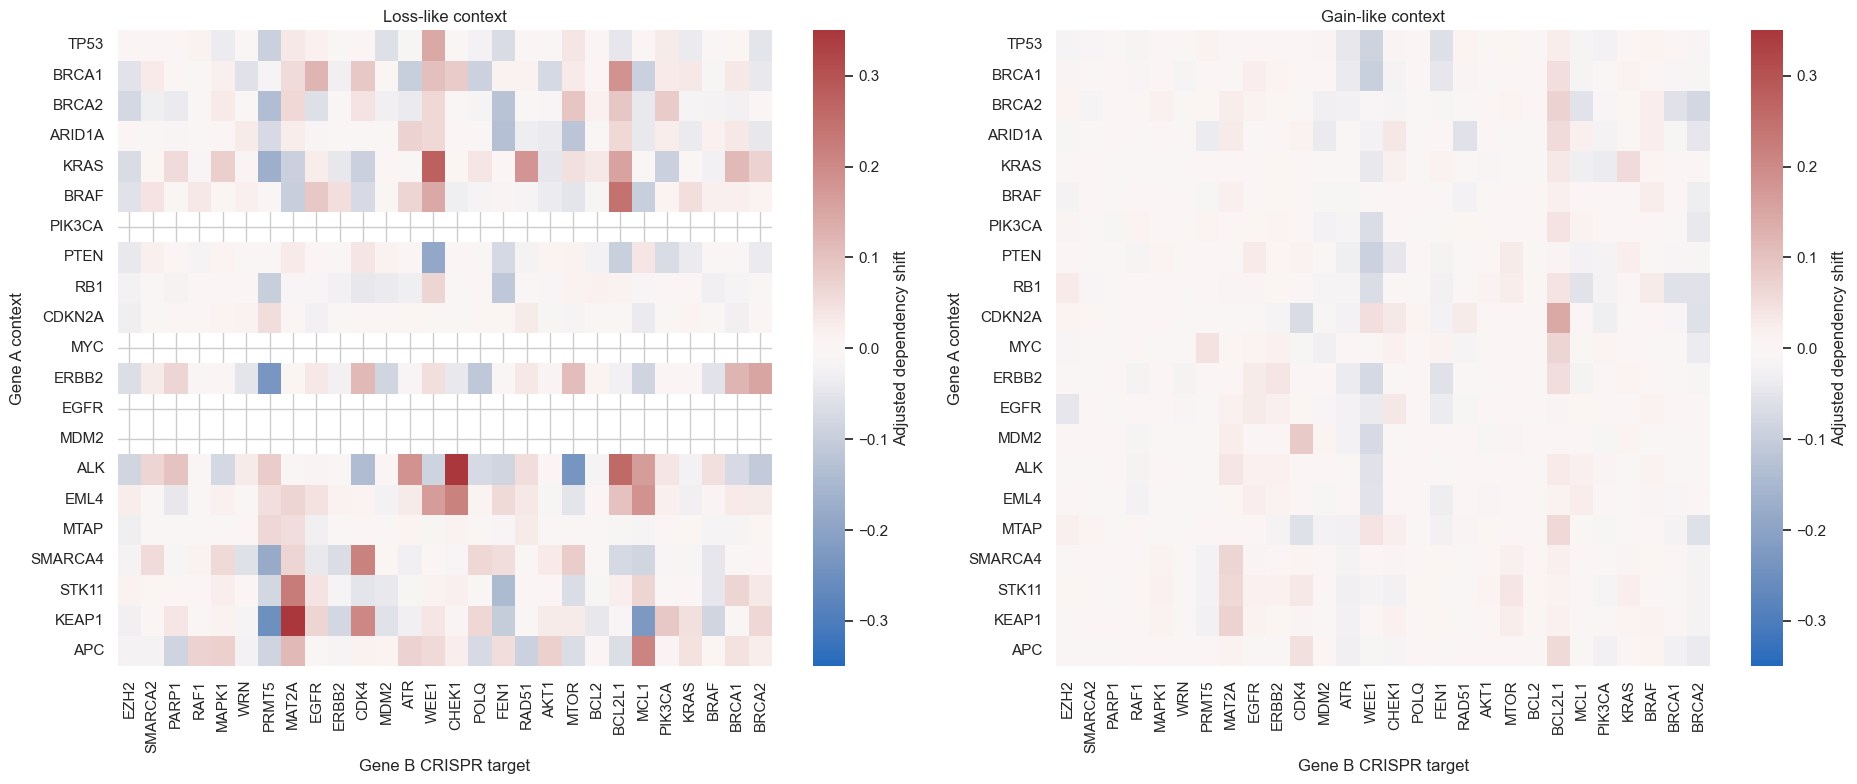

In [5]:
copy_universe = route_ids['Copy number to CRISPR'] & set(copy_number.index)
copy_rows = []
for context_gene in CONTEXT_GENES:
    values = copy_number.loc[sorted(copy_universe), context_gene].dropna()
    reference_set = set(values.index[values.gt(1) & values.lt(4)])
    states = {
        'Loss-like (CN <= 1) vs near-diploid': set(values.index[values.le(1)]),
        'Gain-like (CN >= 4) vs near-diploid': set(values.index[values.ge(4)]),
    }
    for definition, context_set in states.items():
        comparison_masks[('Copy number', context_gene, definition)] = (context_set, reference_set)
        for target_gene in TARGET_GENES:
            stats = dependency_comparison(target_gene, context_set, reference_set, copy_universe)
            copy_rows.append({'context_type': 'Copy number', 'context_name': context_gene, 'target_gene': target_gene, 'context_definition': definition, **stats})

copy_results = pd.DataFrame(copy_rows)
copy_results['is_common_essential'] = copy_results['target_gene'].map(target_common)
copy_results['baseline_median_gene_effect'] = copy_results['target_gene'].map(target_summary.set_index('target_gene')['baseline_median_gene_effect'])
copy_usable = copy_results.loc[
    copy_results['lineage_adjusted_context_models'].ge(10)
    & copy_results['lineage_adjusted_reference_models'].ge(10)
].copy()
display(copy_usable.loc[copy_usable['is_common_essential'].eq(0)].nlargest(30, 'lineage_adjusted_dependency_shift'))

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
for ax, definition, title in [
    (axes[0], 'Loss-like (CN <= 1) vs near-diploid', 'Loss-like context'),
    (axes[1], 'Gain-like (CN >= 4) vs near-diploid', 'Gain-like context'),
]:
    matrix = copy_usable.loc[copy_usable['context_definition'].eq(definition)].pivot(index='context_name', columns='target_gene', values='lineage_adjusted_dependency_shift').reindex(index=CONTEXT_GENES, columns=TARGET_GENES)
    sns.heatmap(matrix, cmap='vlag', center=0, vmin=-0.35, vmax=0.35, ax=ax, cbar_kws={'label': 'Adjusted dependency shift'})
    ax.set_title(title); ax.set_xlabel('Gene B CRISPR target'); ax.set_ylabel('Gene A context')
plt.tight_layout(); plt.show()

### What this means for the project

Copy-number loss and gain are different hypotheses. A loss can remove a tumour suppressor or a neighbouring gene, while a gain can create oncogene addiction or reflect a larger amplified region.

The heatmaps show direction and missing denominators. Blank cells mean the group-size rules were not met; they do not mean no biological relationship exists.

**Example:** MTAP loss can be tested against PRMT5 and MAT2A dependency. Because both targets are common-essential in this release, a useful explanation must distinguish an additional MTAP-associated shift from their broad baseline importance.

## 5. RNA context to CRISPR dependency

For each lineage with at least 15 measured models, Gene A RNA-high models are the top 20% and RNA-low models are the bottom 20%. Middle models are excluded from the categorical comparison. A continuous lineage-adjusted association is also reported.

,context_type,context_name,target_gene,context_definition,continuous_models,continuous_dependency_rho,context_models,reference_models,median_gene_effect_context,median_gene_effect_reference,dependency_shift,dependency_rank_effect,dependency_probability_shift,lineage_adjusted_models,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift,lineage_adjusted_rank_effect,is_common_essential,baseline_median_gene_effect
375,RNA,MDM2,MDM2,Within-lineage high versus low RNA,1070,0.424918,222,222,-0.897493,-0.334382,0.563111,0.574385,0.645682,340,170,170,0.474305,0.647336,0,-0.377859
136,RNA,KRAS,KRAS,Within-lineage high versus low RNA,1070,0.136752,222,223,-0.417030,-0.340443,0.076587,0.220781,0.162316,341,170,171,0.119413,0.286825,0,-0.373204
317,RNA,ERBB2,ERBB2,Within-lineage high versus low RNA,1070,0.211460,222,222,-0.331641,-0.226887,0.104754,0.313246,0.120462,340,170,170,0.086996,0.368512,0,-0.251257
316,RNA,ERBB2,EGFR,Within-lineage high versus low RNA,1070,0.159761,222,222,-0.244999,-0.164224,0.080775,0.217555,0.061368,340,170,170,0.071461,0.214464,0,-0.188838
476,RNA,SMARCA4,EZH2,Within-lineage high versus low RNA,1070,0.106962,222,222,-0.069893,-0.028666,0.041226,0.151773,0.010470,340,170,170,0.064940,0.179170,0,-0.047158
527,RNA,STK11,PIK3CA,Within-lineage high versus low RNA,1070,0.010572,223,222,-0.441829,-0.399191,0.042639,0.057690,0.100775,341,171,170,0.049623,0.051737,0,-0.426307
171,RNA,PIK3CA,RAF1,Within-lineage high versus low RNA,1070,0.065303,222,222,-0.176826,-0.153484,0.023342,0.083394,0.025141,340,170,170,0.042380,0.165052,0,-0.155475
379,RNA,MDM2,POLQ,Within-lineage high versus low RNA,1070,0.109280,222,222,-0.297132,-0.240380,0.056752,0.192882,0.040596,340,170,170,0.041926,0.211972,0,-0.265398
344,RNA,EGFR,EGFR,Within-lineage high versus low RNA,1070,0.142606,222,233,-0.216119,-0.159312,0.056807,0.134632,0.040422,351,170,181,0.039113,0.155671,0,-0.188838
448,RNA,MTAP,EZH2,Within-lineage high versus low RNA,1070,0.078054,222,226,-0.044782,-0.018778,0.026004,0.104959,0.006354,343,170,173,0.037940,0.183135,0,-0.047158


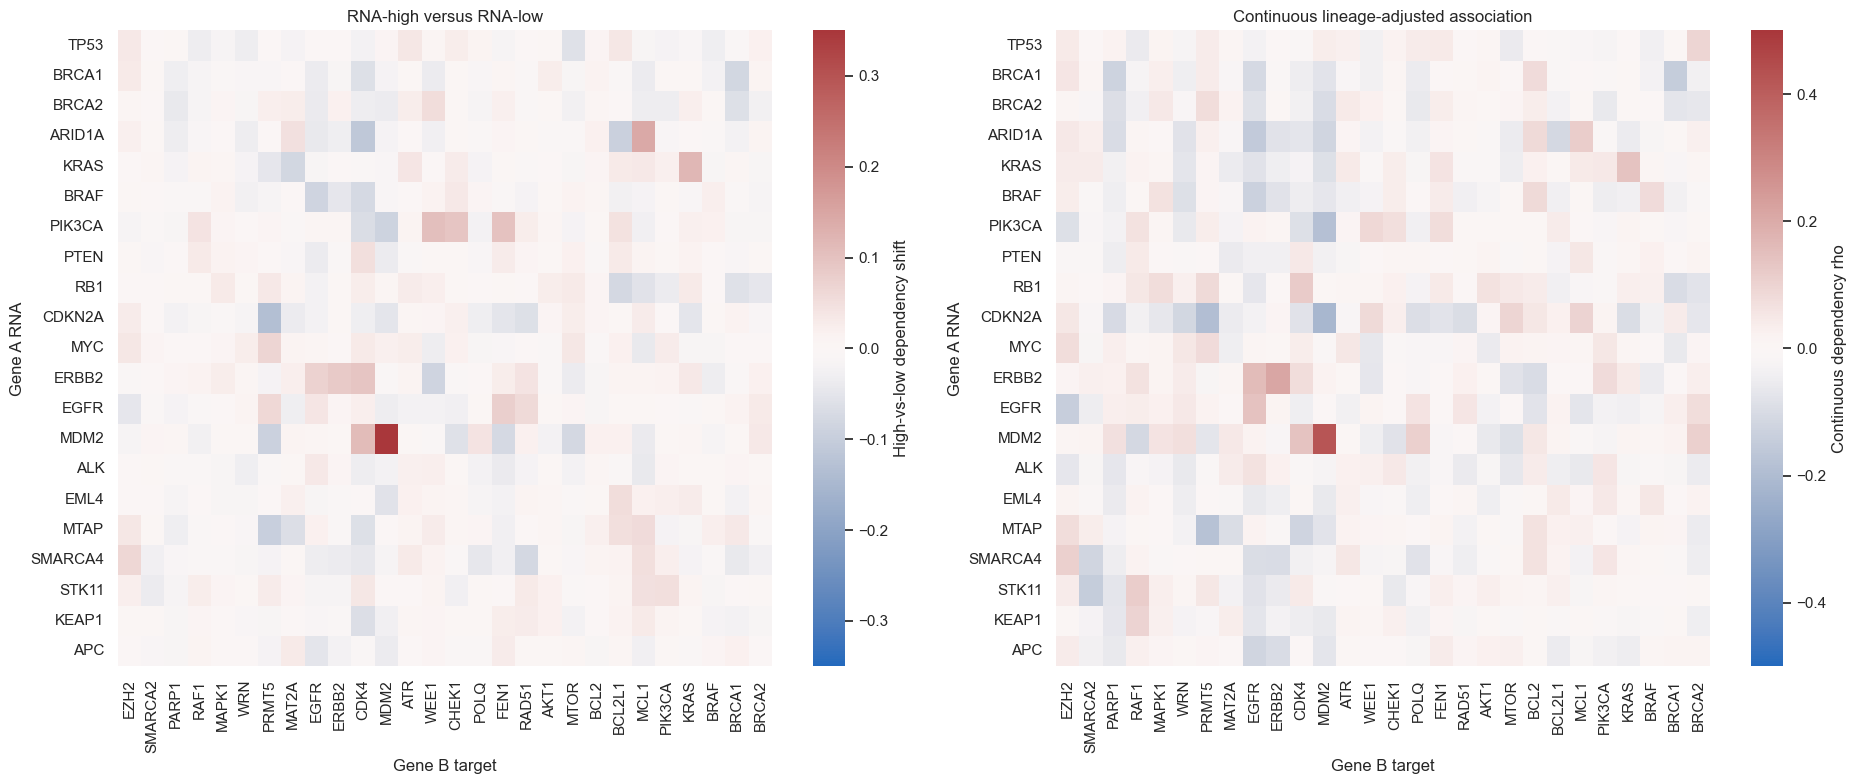

In [6]:
rna_universe = route_ids['RNA to CRISPR'] & set(expression.index)
rna_rows = []
rna_definition = 'Within-lineage high versus low RNA'
for context_gene in CONTEXT_GENES:
    high_set, low_set = within_lineage_extremes(expression[context_gene], rna_universe)
    comparison_masks[('RNA', context_gene, rna_definition)] = (high_set, low_set)
    for target_gene in TARGET_GENES:
        stats = dependency_comparison(target_gene, high_set, low_set, rna_universe)
        continuous_n, continuous_rho = continuous_dependency_association(expression[context_gene], target_gene, rna_universe)
        rna_rows.append({'context_type': 'RNA', 'context_name': context_gene, 'target_gene': target_gene, 'context_definition': rna_definition, 'continuous_models': continuous_n, 'continuous_dependency_rho': continuous_rho, **stats})

rna_results = pd.DataFrame(rna_rows)
rna_results['is_common_essential'] = rna_results['target_gene'].map(target_common)
rna_results['baseline_median_gene_effect'] = rna_results['target_gene'].map(target_summary.set_index('target_gene')['baseline_median_gene_effect'])
rna_usable = rna_results.loc[
    rna_results['lineage_adjusted_context_models'].ge(10)
    & rna_results['lineage_adjusted_reference_models'].ge(10)
].copy()
display(rna_usable.loc[rna_usable['is_common_essential'].eq(0)].nlargest(30, 'lineage_adjusted_dependency_shift'))

rna_matrix = rna_usable.pivot(index='context_name', columns='target_gene', values='lineage_adjusted_dependency_shift').reindex(index=CONTEXT_GENES, columns=TARGET_GENES)
rho_matrix = rna_usable.pivot(index='context_name', columns='target_gene', values='continuous_dependency_rho').reindex(index=CONTEXT_GENES, columns=TARGET_GENES)
fig, axes = plt.subplots(1, 2, figsize=(19, 8))
sns.heatmap(rna_matrix, cmap='vlag', center=0, vmin=-0.35, vmax=0.35, ax=axes[0], cbar_kws={'label': 'High-vs-low dependency shift'})
axes[0].set_title('RNA-high versus RNA-low'); axes[0].set_xlabel('Gene B target'); axes[0].set_ylabel('Gene A RNA')
sns.heatmap(rho_matrix, cmap='vlag', center=0, vmin=-0.5, vmax=0.5, ax=axes[1], cbar_kws={'label': 'Continuous dependency rho'})
axes[1].set_title('Continuous lineage-adjusted association'); axes[1].set_xlabel('Gene B target'); axes[1].set_ylabel('Gene A RNA')
plt.tight_layout(); plt.show()

### What this means for the project

RNA-high and RNA-low are defined within lineage so a naturally high-expression tissue is not automatically compared with a naturally low-expression tissue. The continuous statistic checks whether the direction is visible across more than the extreme groups.

RNA association can reflect pathway activity, cell state, or lineage rather than a direct physical relationship. It is weaker evidence when the categorical and continuous directions disagree.

**Example:** EGFR-high models can be tested for EGFR knockout dependency as an oncogene-addiction pattern. This is a same-gene example that validates the method before using Gene A and Gene B as different genes.

## 6. Genomic signatures to CRISPR dependency

Continuous signatures use within-lineage top-versus-bottom quintiles. WGD is already binary and is compared as WGD-present versus WGD-absent.

,context_type,context_name,target_gene,context_definition,continuous_models,continuous_dependency_rho,context_models,reference_models,median_gene_effect_context,median_gene_effect_reference,dependency_shift,dependency_rank_effect,dependency_probability_shift,lineage_adjusted_models,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift,lineage_adjusted_rank_effect,is_common_essential,baseline_median_gene_effect
121,Signature,CIN,ERBB2,Within-lineage high versus low signature,905,0.108534,191,191,-0.304199,-0.241117,0.063081,0.177709,0.065826,270,135,135,0.078081,0.276049,0,-0.251257
23,Signature,MSIScore,PIK3CA,Within-lineage high versus low signature,1143,0.052463,237,238,-0.435353,-0.407318,0.028035,0.065348,0.056546,399,199,200,0.037237,0.139698,0,-0.426307
83,Signature,LoHFraction,BRCA2,Within-lineage high versus low signature,905,0.011573,191,191,-0.495359,-0.461787,0.033572,0.039664,0.062485,270,135,135,0.036932,0.068422,0,-0.474076
137,Signature,CIN,BRAF,Within-lineage high versus low signature,905,0.054204,191,191,-0.037717,-0.019949,0.017768,0.096845,0.010472,270,135,135,0.029699,0.158299,0,-0.030936
37,Signature,Ploidy,ERBB2,Within-lineage high versus low signature,905,0.099516,191,191,-0.280229,-0.240735,0.039494,0.148982,0.041866,270,135,135,0.024313,0.153032,0,-0.251257
27,Signature,MSIScore,BRCA2,Within-lineage high versus low signature,1143,0.055905,237,238,-0.482822,-0.445535,0.037287,0.129029,0.087478,399,199,200,0.018704,0.103015,0,-0.474076
53,Signature,Ploidy,BRAF,Within-lineage high versus low signature,905,0.033606,191,191,-0.043199,-0.019400,0.023799,0.103862,0.010171,270,135,135,0.017081,0.124280,0,-0.030936
43,Signature,Ploidy,POLQ,Within-lineage high versus low signature,905,-0.009301,191,191,-0.264193,-0.256482,0.007711,0.006716,0.008219,270,135,135,0.017027,0.040110,0,-0.265398
93,Signature,WGD,ERBB2,WGD present versus absent,948,NaN,697,251,-0.274716,-0.210638,0.064078,0.252482,0.086858,905,670,235,0.015626,0.115592,0,-0.251257
57,Signature,LoHFraction,SMARCA2,Within-lineage high versus low signature,905,0.030881,191,191,-0.001393,0.014804,0.016197,0.091198,0.004703,270,135,135,0.015241,0.139863,0,0.012674


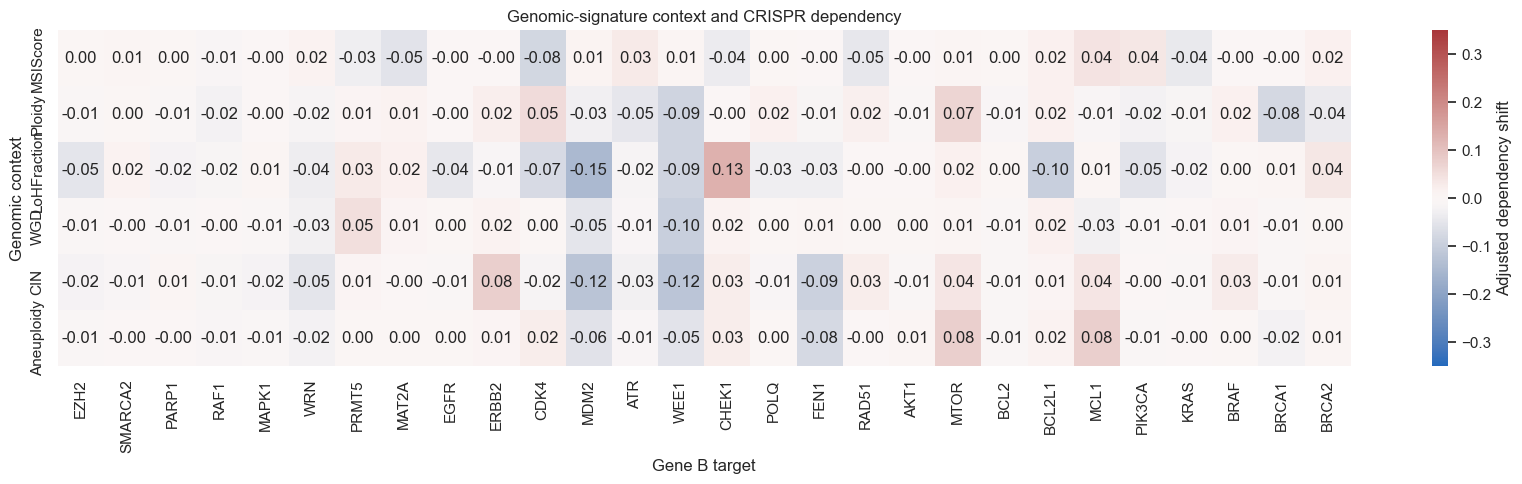

In [7]:
signature_universe = route_ids['Signatures to CRISPR'] & set(signatures.index)
signature_rows = []
signature_columns = ['MSIScore', 'Ploidy', 'LoHFraction', 'WGD', 'CIN', 'Aneuploidy']
for signature in signature_columns:
    values = signatures[signature]
    if signature == 'WGD':
        measured = values.reindex(sorted(signature_universe)).dropna()
        context_set = set(measured.index[measured.eq(1)])
        reference_set = set(measured.index[measured.eq(0)])
        definition = 'WGD present versus absent'
    else:
        context_set, reference_set = within_lineage_extremes(values, signature_universe)
        definition = 'Within-lineage high versus low signature'
    comparison_masks[('Signature', signature, definition)] = (context_set, reference_set)
    for target_gene in TARGET_GENES:
        stats = dependency_comparison(target_gene, context_set, reference_set, signature_universe)
        continuous_n, continuous_rho = continuous_dependency_association(values, target_gene, signature_universe) if signature != 'WGD' else (len(context_set | reference_set), np.nan)
        signature_rows.append({'context_type': 'Signature', 'context_name': signature, 'target_gene': target_gene, 'context_definition': definition, 'continuous_models': continuous_n, 'continuous_dependency_rho': continuous_rho, **stats})

signature_results = pd.DataFrame(signature_rows)
signature_results['is_common_essential'] = signature_results['target_gene'].map(target_common)
signature_results['baseline_median_gene_effect'] = signature_results['target_gene'].map(target_summary.set_index('target_gene')['baseline_median_gene_effect'])
signature_usable = signature_results.loc[
    signature_results['lineage_adjusted_context_models'].ge(10)
    & signature_results['lineage_adjusted_reference_models'].ge(10)
].copy()
display(signature_usable.loc[signature_usable['is_common_essential'].eq(0)].nlargest(30, 'lineage_adjusted_dependency_shift'))

signature_matrix = signature_usable.pivot(index='context_name', columns='target_gene', values='lineage_adjusted_dependency_shift').reindex(index=signature_columns, columns=TARGET_GENES)
plt.figure(figsize=(17, 5))
sns.heatmap(signature_matrix, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-0.35, vmax=0.35, cbar_kws={'label': 'Adjusted dependency shift'})
plt.title('Genomic-signature context and CRISPR dependency')
plt.xlabel('Gene B target'); plt.ylabel('Genomic context')
plt.tight_layout(); plt.show()

### What this means for the project

Signatures describe genome-wide states rather than one altered gene. They can reveal dependencies caused by DNA-repair defects, chromosome instability, or whole-genome duplication.

Signature-high versus low is an EDA definition based on this dataset. It must stay visible in any feature or dashboard explanation.

**Example:** high MSI score can be tested against WRN dependency. A positive shift means MSI-high models are more harmed by WRN knockout, but the result still needs group sizes, lineage checks, and external validation.

## 7. Hypothesis examples across routes

These examples demonstrate how known or plausible biological hypotheses appear under the same transparent statistics. They are not assumed to be correct before inspecting the data.

,pair,context_type,context_definition,hypothesis,context_models,reference_models,dependency_shift,dependency_probability_shift,lineage_adjusted_context_models,lineage_adjusted_reference_models,lineage_adjusted_dependency_shift,is_common_essential,baseline_median_gene_effect
0,ARID1A -> EZH2,Mutation,Damaging or driver-like,Chromatin-state conditional dependency,118,1060,0.022384,0.007451,116,1027,0.033661,0,-0.047158
1,SMARCA4 -> SMARCA2,Mutation,Damaging or driver-like,Paralog dependency,64,1114,0.107650,0.023159,61,1082,0.098584,0,0.012674
2,BRCA1 -> PARP1,Mutation,Damaging or driver-like,DNA-repair vulnerability,21,1157,0.047145,0.054422,21,1122,0.083418,0,-0.169220
3,BRCA2 -> PARP1,Mutation,Damaging or driver-like,DNA-repair vulnerability,36,1142,0.027853,0.034417,34,1109,0.045164,0,-0.169220
4,KRAS -> RAF1,Mutation,Damaging or driver-like,Oncogenic signalling dependency,176,1002,0.205490,0.228858,173,970,0.103703,0,-0.155475
5,MTAP -> PRMT5,Copy number,Loss-like (CN <= 1) vs near-diploid,Metabolic vulnerability; common-essential target,305,517,0.062779,0.008690,297,478,0.065392,1,-1.016544
6,MTAP -> MAT2A,Copy number,Loss-like (CN <= 1) vs near-diploid,Metabolic vulnerability; common-essential target,305,517,0.076820,0.000031,297,478,0.054054,1,-1.748636
7,ERBB2 -> ERBB2,Copy number,Gain-like (CN >= 4) vs near-diploid,Oncogene addiction,322,613,0.070772,0.073974,308,584,0.039291,0,-0.251257
8,EGFR -> EGFR,RNA,Within-lineage high versus low RNA,Expression-linked oncogene addiction,222,233,0.056807,0.040422,170,181,0.039113,0,-0.188838
9,MSIScore -> WRN,Signature,Within-lineage high versus low signature,Genome-instability vulnerability,237,238,0.018488,0.005271,199,200,0.015141,0,-0.054037


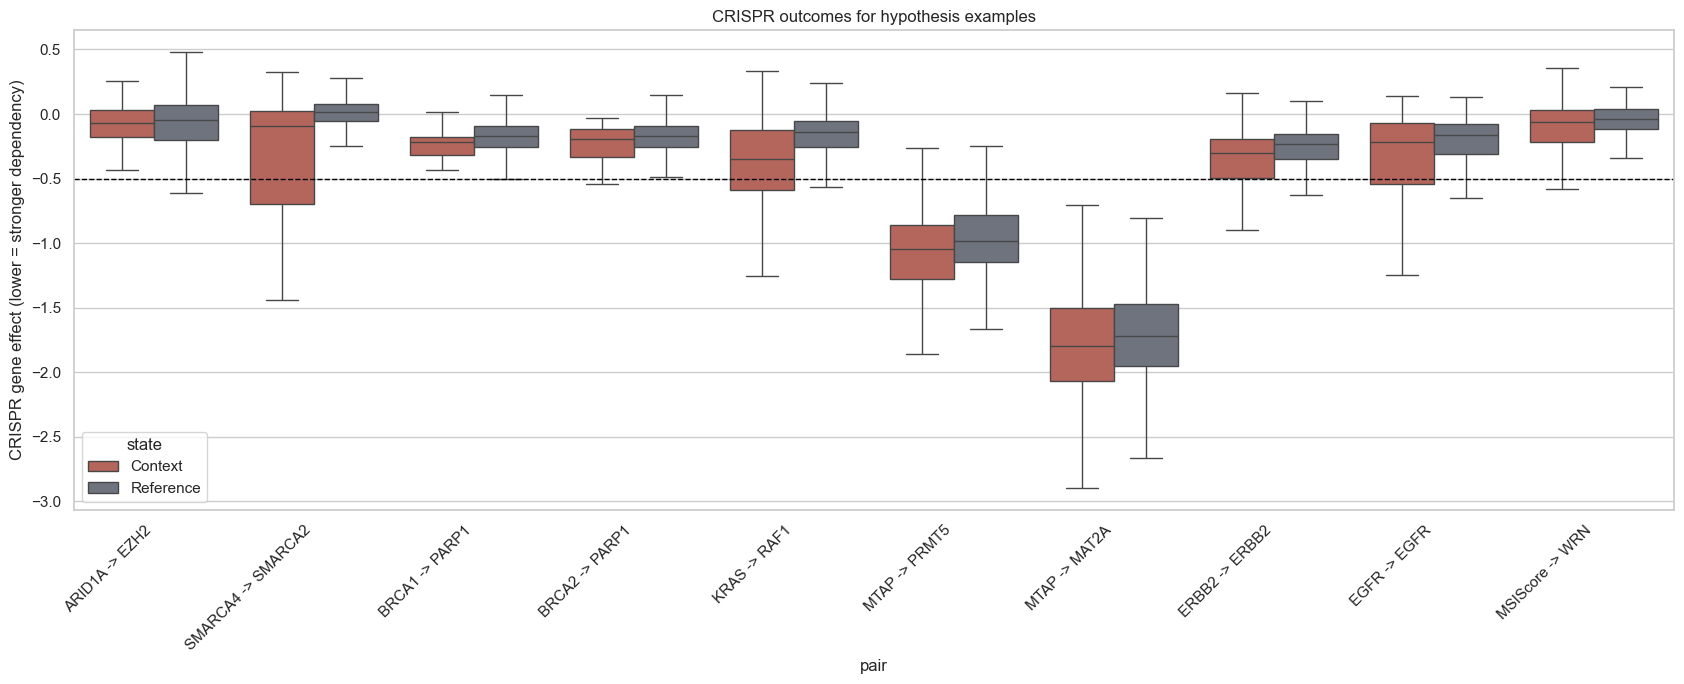

In [8]:
all_results = pd.concat([mutation_results, copy_results, rna_results, signature_results], ignore_index=True, sort=False)
example_specs = pd.DataFrame([
    {'context_type': 'Mutation', 'context_name': 'ARID1A', 'target_gene': 'EZH2', 'context_definition': 'Damaging or driver-like', 'hypothesis': 'Chromatin-state conditional dependency'},
    {'context_type': 'Mutation', 'context_name': 'SMARCA4', 'target_gene': 'SMARCA2', 'context_definition': 'Damaging or driver-like', 'hypothesis': 'Paralog dependency'},
    {'context_type': 'Mutation', 'context_name': 'BRCA1', 'target_gene': 'PARP1', 'context_definition': 'Damaging or driver-like', 'hypothesis': 'DNA-repair vulnerability'},
    {'context_type': 'Mutation', 'context_name': 'BRCA2', 'target_gene': 'PARP1', 'context_definition': 'Damaging or driver-like', 'hypothesis': 'DNA-repair vulnerability'},
    {'context_type': 'Mutation', 'context_name': 'KRAS', 'target_gene': 'RAF1', 'context_definition': 'Damaging or driver-like', 'hypothesis': 'Oncogenic signalling dependency'},
    {'context_type': 'Copy number', 'context_name': 'MTAP', 'target_gene': 'PRMT5', 'context_definition': 'Loss-like (CN <= 1) vs near-diploid', 'hypothesis': 'Metabolic vulnerability; common-essential target'},
    {'context_type': 'Copy number', 'context_name': 'MTAP', 'target_gene': 'MAT2A', 'context_definition': 'Loss-like (CN <= 1) vs near-diploid', 'hypothesis': 'Metabolic vulnerability; common-essential target'},
    {'context_type': 'Copy number', 'context_name': 'ERBB2', 'target_gene': 'ERBB2', 'context_definition': 'Gain-like (CN >= 4) vs near-diploid', 'hypothesis': 'Oncogene addiction'},
    {'context_type': 'RNA', 'context_name': 'EGFR', 'target_gene': 'EGFR', 'context_definition': 'Within-lineage high versus low RNA', 'hypothesis': 'Expression-linked oncogene addiction'},
    {'context_type': 'Signature', 'context_name': 'MSIScore', 'target_gene': 'WRN', 'context_definition': 'Within-lineage high versus low signature', 'hypothesis': 'Genome-instability vulnerability'},
])

example_results = example_specs.merge(
    all_results,
    on=['context_type', 'context_name', 'target_gene', 'context_definition'],
    how='left', validate='one_to_one'
)
example_results['pair'] = example_results['context_name'] + ' -> ' + example_results['target_gene']
display(example_results[[
    'pair', 'context_type', 'context_definition', 'hypothesis', 'context_models', 'reference_models',
    'dependency_shift', 'dependency_probability_shift', 'lineage_adjusted_context_models',
    'lineage_adjusted_reference_models', 'lineage_adjusted_dependency_shift', 'is_common_essential',
    'baseline_median_gene_effect'
]])

example_plot_rows = []
for _, spec in example_specs.iterrows():
    key = (spec['context_type'], spec['context_name'], spec['context_definition'])
    context_set, reference_set = comparison_masks[key]
    for state, ids in [('Context', context_set), ('Reference', reference_set)]:
        selected_ids = sorted(set(ids) & set(effect.index))
        values = effect.loc[selected_ids, spec['target_gene']].dropna()
        example_plot_rows.append(pd.DataFrame({'pair': f"{spec['context_name']} -> {spec['target_gene']}", 'state': state, 'gene_effect': values.values}))
example_plot = pd.concat(example_plot_rows, ignore_index=True)

plt.figure(figsize=(17, 7))
sns.boxplot(data=example_plot, x='pair', y='gene_effect', hue='state', showfliers=False, palette={'Context': '#c45b4d', 'Reference': '#6b7280'})
plt.axhline(-0.5, color='black', linestyle='--', linewidth=1, label='Example strong-effect reference')
plt.xticks(rotation=45, ha='right'); plt.ylabel('CRISPR gene effect (lower = stronger dependency)')
plt.title('CRISPR outcomes for hypothesis examples')
plt.tight_layout(); plt.show()

### What this means for the project

The examples put every route on the same directional scale while preserving different biological definitions. A pair can look convincing on raw values but weaken after lineage adjustment or reveal an unbalanced context group.

Same-gene oncogene-addiction examples such as ERBB2 gain to ERBB2 dependency provide useful method checks. Different-gene hypotheses such as SMARCA4 to SMARCA2 are closer to the final gene-pair objective.

**Example:** a positive MTAP-to-PRMT5 shift is not enough to call a selective dependency because PRMT5 is flagged as common essential. The shift, baseline, and target warning belong together.

## 8. Lineage robustness of hypothesis examples

Each example is recalculated inside a lineage only when at least five context and five reference models are available. These are exploratory lineage checks; stronger modelling will require larger groups.

,pair,evaluable_lineages
0,ARID1A -> EZH2,8
1,SMARCA4 -> SMARCA2,2
2,BRCA1 -> PARP1,2
3,BRCA2 -> PARP1,3
4,KRAS -> RAF1,7
5,MTAP -> PRMT5,17
6,MTAP -> MAT2A,17
7,ERBB2 -> ERBB2,20
8,EGFR -> EGFR,20
9,MSIScore -> WRN,20


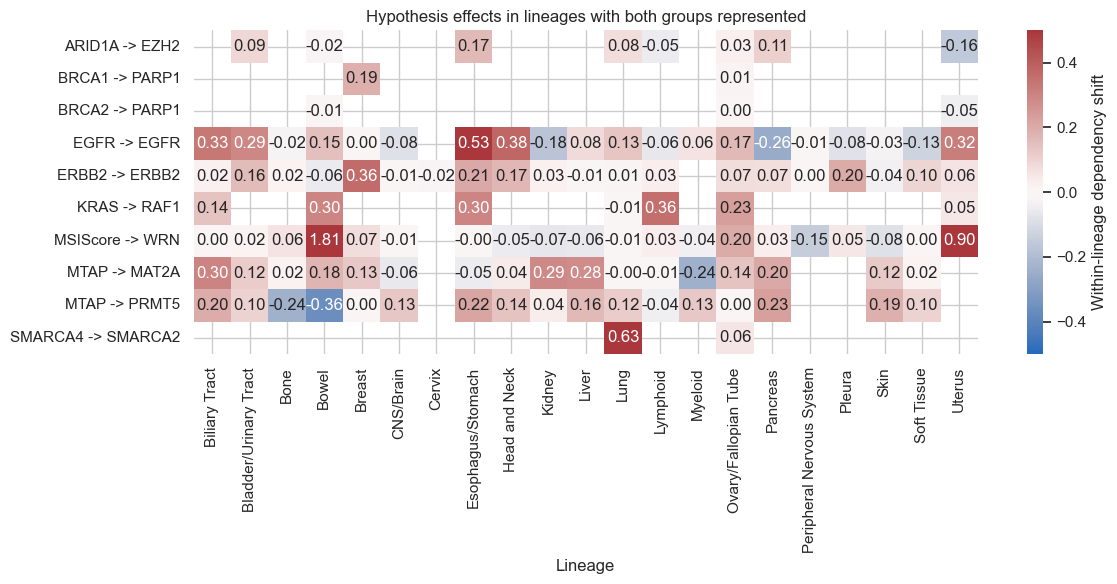

In [9]:
lineage_rows = []
for _, spec in example_specs.iterrows():
    key = (spec['context_type'], spec['context_name'], spec['context_definition'])
    context_set, reference_set = comparison_masks[key]
    for lineage, lineage_ids in lineage_lookup.groupby(lineage_lookup).groups.items():
        lineage_set = set(lineage_ids)
        context_lineage = context_set & lineage_set & set(effect.index)
        reference_lineage = reference_set & lineage_set & set(effect.index)
        if len(context_lineage) < 5 or len(reference_lineage) < 5:
            continue
        context_values = effect.loc[sorted(context_lineage), spec['target_gene']].dropna()
        reference_values = effect.loc[sorted(reference_lineage), spec['target_gene']].dropna()
        if len(context_values) < 5 or len(reference_values) < 5:
            continue
        lineage_rows.append({
            'pair': f"{spec['context_name']} -> {spec['target_gene']}",
            'lineage': lineage,
            'context_models': len(context_values),
            'reference_models': len(reference_values),
            'dependency_shift': reference_values.median() - context_values.median(),
        })

lineage_results = pd.DataFrame(lineage_rows)
evaluable = lineage_results.groupby('pair')['lineage'].nunique().rename('evaluable_lineages').reset_index() if not lineage_results.empty else pd.DataFrame(columns=['pair', 'evaluable_lineages'])
display(example_results[['pair']].merge(evaluable, on='pair', how='left').fillna({'evaluable_lineages': 0}))
if not lineage_results.empty:
    lineage_matrix = lineage_results.pivot(index='pair', columns='lineage', values='dependency_shift')
    plt.figure(figsize=(max(12, 0.55 * len(lineage_matrix.columns)), 6))
    sns.heatmap(lineage_matrix, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-0.5, vmax=0.5, cbar_kws={'label': 'Within-lineage dependency shift'})
    plt.title('Hypothesis effects in lineages with both groups represented')
    plt.xlabel('Lineage'); plt.ylabel('')
    plt.tight_layout(); plt.show()

### What this means for the project

An overall effect is more credible when its direction can be checked in more than one adequately represented lineage. Blank cells usually mean the altered context is too rare in that lineage, not that the effect is absent.

This view also identifies hypotheses that are inherently lineage-specific. Such pairs should be reported in that disease context rather than assigned one universal percentage across every cell line.

**Example:** a mutation may occur mainly in one cancer type. In that case the dashboard should say the evidence is lineage-limited instead of presenting the pooled effect as universal biology.

## 9. CRISPR QC and library sensitivity

All released CRISPR models have at least one passing screen. Numerical QC, growth, and efficacy outliers are marked within exact library groups using the IQR rule. They remain in the primary analysis and are removed only in a labelled sensitivity comparison.

,inference_libraries,models
0,Achilles-Avana-2D,829
1,Achilles-Avana-2D|Achilles-KY-2D,190
2,Achilles-KY-2D,119
3,Achilles-Avana-2D|Achilles-Humagne-CD-2D,18
4,Achilles-Humagne-CD-2D,16
5,Achilles-Avana-2D|Achilles-Humagne-CD-2D|Achil...,6


,count,mean,std,min,25%,50%,75%,max
any_screen_passes_qc,1178.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
all_screens_pass_qc,1178.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
n_numeric_review_flags,1178.0,0.162988,0.507134,0.000000,0.000000,0.000000,0.000000,4.000000
mean_screen_roc_auc,1178.0,0.943375,0.041581,0.702246,0.928853,0.954777,0.971484,0.992145
mean_screen_fpr,1178.0,0.047460,0.017888,0.013793,0.034483,0.045517,0.056552,0.201379
mean_screen_nnmd,1178.0,-7.432190,2.820631,-17.319611,-9.239432,-7.218193,-5.398768,-1.275920
mean_cas_activity,1047.0,75.571070,15.342467,10.000000,65.000000,79.800000,88.200000,99.600000
median_screen_doubling_time,1019.0,61.069774,38.996104,20.000000,41.000000,52.000000,72.000000,938.000000
mean_inferred_model_efficacy,1178.0,0.780938,0.171298,0.127126,0.697854,0.824972,0.913522,0.990750
mean_inferred_model_growth_rate,1178.0,1.005621,0.180406,0.543182,0.879027,0.994944,1.127416,1.724346


,pair,analysis_subset,context_models,reference_models,dependency_shift,lineage_adjusted_dependency_shift
0,ARID1A -> EZH2,All released models,118,1060,0.022384,0.033661
1,ARID1A -> EZH2,No numerical review flags,104,936,0.020624,0.018620
2,ARID1A -> EZH2,Avana only,75,754,0.011858,0.012518
3,ARID1A -> EZH2,KY only,12,107,0.013635,NaN
4,ARID1A -> EZH2,Multiple libraries,31,183,0.076438,0.059004
5,SMARCA4 -> SMARCA2,All released models,64,1114,0.107650,0.098584
6,SMARCA4 -> SMARCA2,No numerical review flags,56,984,0.111216,0.098970
7,SMARCA4 -> SMARCA2,Avana only,46,783,0.132853,0.151220
8,SMARCA4 -> SMARCA2,Multiple libraries,16,198,0.071074,0.125575
9,BRCA1 -> PARP1,All released models,21,1157,0.047145,0.083418


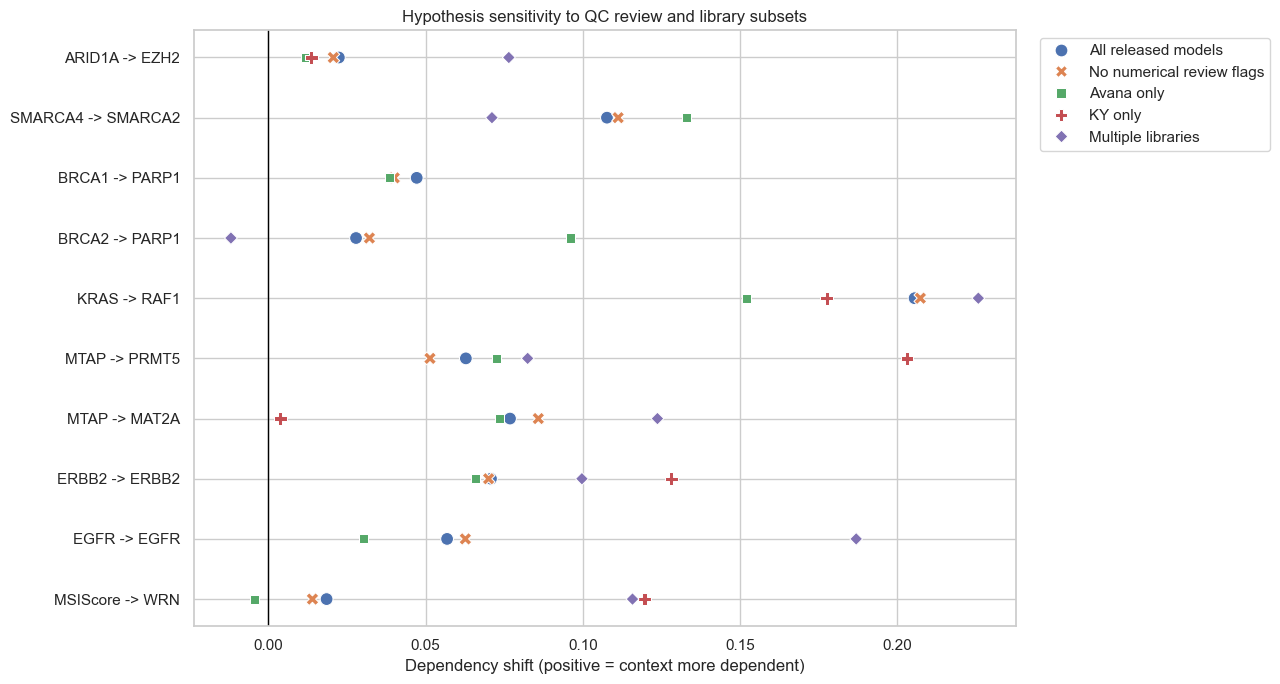

In [10]:
qc_metrics = [
    'mean_screen_roc_auc', 'mean_screen_fpr', 'mean_screen_nnmd', 'mean_cas_activity',
    'median_screen_doubling_time', 'mean_inferred_model_efficacy', 'mean_inferred_model_growth_rate'
]
qc = crispr_context.set_index('model_id').copy()
review_columns = []
for metric in qc_metrics:
    q1 = qc.groupby('inference_libraries')[metric].transform(lambda s: s.quantile(0.25))
    q3 = qc.groupby('inference_libraries')[metric].transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    flag = qc[metric].notna() & iqr.gt(0) & ((qc[metric] < q1 - 1.5 * iqr) | (qc[metric] > q3 + 1.5 * iqr))
    column = f'review__{metric}'
    qc[column] = flag
    review_columns.append(column)
qc['n_numeric_review_flags'] = qc[review_columns].sum(axis=1)

display(qc['inference_libraries'].value_counts().rename_axis('inference_libraries').reset_index(name='models'))
display(qc[['any_screen_passes_qc', 'all_screens_pass_qc', 'n_numeric_review_flags', *qc_metrics]].describe().T)

subsets = {
    'All released models': set(qc.index),
    'No numerical review flags': set(qc.index[qc['n_numeric_review_flags'].eq(0)]),
    'Avana only': set(qc.index[qc['inference_libraries'].eq('Achilles-Avana-2D')]),
    'KY only': set(qc.index[qc['inference_libraries'].eq('Achilles-KY-2D')]),
    'Multiple libraries': set(qc.index[qc['n_inference_libraries'].gt(1)]),
}

sensitivity_rows = []
for _, spec in example_specs.iterrows():
    key = (spec['context_type'], spec['context_name'], spec['context_definition'])
    context_set, reference_set = comparison_masks[key]
    for subset_name, subset_ids in subsets.items():
        stats = dependency_comparison(spec['target_gene'], context_set, reference_set, subset_ids)
        if stats['context_models'] < 10 or stats['reference_models'] < 10:
            continue
        sensitivity_rows.append({'pair': f"{spec['context_name']} -> {spec['target_gene']}", 'analysis_subset': subset_name, **stats})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity[['pair', 'analysis_subset', 'context_models', 'reference_models', 'dependency_shift', 'lineage_adjusted_dependency_shift']])

plt.figure(figsize=(13, 7))
sns.scatterplot(data=sensitivity, x='dependency_shift', y='pair', hue='analysis_subset', style='analysis_subset', s=85)
plt.axvline(0, color='black', linewidth=1)
plt.title('Hypothesis sensitivity to QC review and library subsets')
plt.xlabel('Dependency shift (positive = context more dependent)'); plt.ylabel('')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### What this means for the project

All models pass the released screen criteria, so a pass/fail filter does not distinguish this cohort. The useful audit is whether example effects remain similar after flagged numerical extremes are removed and across sufficiently large library subsets.

Growth rate, Cas activity, efficacy, and QC are confidence or confounding context. They are never interpreted as evidence that a gene pair is biologically valid.

**Example:** if a pair's positive shift appears only in one CRISPR library and changes direction elsewhere, the result should receive a stability warning rather than a confident biological explanation.

## 10. Feature-engineering decisions

The final outputs define transparent candidate features and the context that must travel with them.

In [11]:
feature_candidates = pd.DataFrame([
    {'candidate_feature': 'conditional_dependency_shift', 'meaning': 'Median Gene B effect is more dependency-like in the Gene A context', 'required_companions': 'context definition, both group sizes, lineage-adjusted shift'},
    {'candidate_feature': 'conditional_dependency_rank_effect', 'meaning': 'Distribution-level separation between context and reference', 'required_companions': 'both group sizes and sign convention'},
    {'candidate_feature': 'dependency_probability_shift', 'meaning': 'Supporting difference on the inferred probability scale', 'required_companions': 'gene-effect result; never use probability alone'},
    {'candidate_feature': 'continuous_context_dependency_rho', 'meaning': 'Higher RNA/signature value tracks stronger dependency', 'required_companions': 'lineage-adjusted denominator'},
    {'candidate_feature': 'lineage_consistency', 'meaning': 'Direction can be checked in multiple lineages', 'required_companions': 'per-lineage context and reference counts'},
    {'candidate_feature': 'common_essential_warning', 'meaning': 'Target has broad baseline essentiality', 'required_companions': 'baseline median effect and strong-effect prevalence'},
    {'candidate_feature': 'library_qc_stability', 'meaning': 'Effect remains similar in labelled sensitivity subsets', 'required_companions': 'subset names and denominators'},
])

decisions = pd.DataFrame([
    {'decision': 'Primary outcome', 'rule': 'Use CRISPR gene effect; dependency probability is supporting evidence.'},
    {'decision': 'Direction', 'rule': 'Positive engineered shifts always mean context models are more dependent.'},
    {'decision': 'Mutation state', 'rule': 'Retain any-variant and damaging/driver-like definitions separately.'},
    {'decision': 'Copy-number state', 'rule': 'Compare loss and gain separately with a visible near-diploid reference.'},
    {'decision': 'RNA/signature state', 'rule': 'Use within-lineage extremes plus a continuous adjusted association.'},
    {'decision': 'Minimum groups', 'rule': 'Require at least 10 context and 10 reference models after lineage filtering.'},
    {'decision': 'Common essentials', 'rule': 'Flag broad essentiality; do not treat it as selective pair evidence.'},
    {'decision': 'QC and library', 'rule': 'Keep all released models primary and report labelled sensitivity analyses.'},
    {'decision': 'Broad ranking', 'rule': 'Use as EDA lead generation only; validation is required before scoring.'},
])

display(feature_candidates)
display(decisions)

assert effect.index.equals(dependency.index)
assert all(result['context_models'].ge(0).all() for result in [mutation_results, copy_results, rna_results, signature_results])
assert all(result['dependency_shift'].dropna().map(np.isfinite).all() for result in [mutation_results, copy_results, rna_results, signature_results])

,candidate_feature,meaning,required_companions
0,conditional_dependency_shift,Median Gene B effect is more dependency-like i...,"context definition, both group sizes, lineage-..."
1,conditional_dependency_rank_effect,Distribution-level separation between context ...,both group sizes and sign convention
2,dependency_probability_shift,Supporting difference on the inferred probabil...,gene-effect result; never use probability alone
3,continuous_context_dependency_rho,Higher RNA/signature value tracks stronger dep...,lineage-adjusted denominator
4,lineage_consistency,Direction can be checked in multiple lineages,per-lineage context and reference counts
5,common_essential_warning,Target has broad baseline essentiality,baseline median effect and strong-effect preva...
6,library_qc_stability,Effect remains similar in labelled sensitivity...,subset names and denominators


,decision,rule
0,Primary outcome,Use CRISPR gene effect; dependency probability...
1,Direction,Positive engineered shifts always mean context...
2,Mutation state,Retain any-variant and damaging/driver-like de...
3,Copy-number state,Compare loss and gain separately with a visibl...
4,RNA/signature state,Use within-lineage extremes plus a continuous ...
5,Minimum groups,Require at least 10 context and 10 reference m...
6,Common essentials,Flag broad essentiality; do not treat it as se...
7,QC and library,Keep all released models primary and report la...
8,Broad ranking,Use as EDA lead generation only; validation is...


### What this means for the project

This notebook creates the first direct, white-box bridge from molecular data to gene-pair prediction. The useful object is not a mysterious pair score; it is a set of explainable effects with exact definitions, denominators, lineage adjustment, target baseline, and stability context.

The next step should combine these conditional-dependency features with direct fusion evidence and CRISPR codependency. Those routes should remain separate in the model so the dashboard can say **which biological route supported the pair** and how strong that evidence was.